In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [6]:
dataset_path = "C:/Users/ACER/Desktop/SmartKrishi/PlantVillage/train"

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)


In [8]:
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 31174 images belonging to 33 classes.


In [9]:
val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 7777 images belonging to 33 classes.


In [10]:
print(train_data.class_indices)

{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 4, 'Corn_(maize)___Common_rust_': 5, 'Corn_(maize)___Northern_Leaf_Blight': 6, 'Corn_(maize)___healthy': 7, 'Grape___Black_rot': 8, 'Grape___Esca_(Black_Measles)': 9, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 10, 'Grape___healthy': 11, 'Orange___Haunglongbing_(Citrus_greening)': 12, 'Peach___Bacterial_spot': 13, 'Peach___healthy': 14, 'Pepper,_bell___Bacterial_spot': 15, 'Pepper,_bell___healthy': 16, 'Potato___Early_blight': 17, 'Potato___Late_blight': 18, 'Potato___healthy': 19, 'Soybean___healthy': 20, 'Strawberry___Leaf_scorch': 21, 'Strawberry___healthy': 22, 'Tomato___Bacterial_spot': 23, 'Tomato___Early_blight': 24, 'Tomato___Late_blight': 25, 'Tomato___Leaf_Mold': 26, 'Tomato___Septoria_leaf_spot': 27, 'Tomato___Spider_mites Two-spotted_spider_mite': 28, 'Tomato___Target_Spot': 29, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus

In [11]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [12]:
for layer in base_model.layers:
    layer.trainable = False

In [13]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

predictions = layers.Dense(train_data.num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=predictions)

In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,426,209 (9.26 MB)

 Trainable params: 168,225 (657.13 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10


c:\Users\ACER\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


975/975 ━━━━━━━━━━━━━━━━━━━━ 2209s 2s/step - accuracy: 0.5876 - loss: 1.5167 - val_accuracy: 0.8996 - val_loss: 0.3325
Epoch 2/10
975/975 ━━━━━━━━━━━━━━━━━━━━ 3898s 4s/step - accuracy: 0.8177 - loss: 0.5688 - val_accuracy: 0.9061 - val_loss: 0.2773
Epoch 3/10
975/975 ━━━━━━━━━━━━━━━━━━━━ 3352s 3s/step - accuracy: 0.8462 - loss: 0.4763 - val_accuracy: 0.9167 - val_loss: 0.2523
Epoch 4/10
975/975 ━━━━━━━━━━━━━━━━━━━━ 3184s 3s/step - accuracy: 0.8616 - loss: 0.4341 - val_accuracy: 0.9270 - val_loss: 0.2208
Epoch 5/10
975/975 ━━━━━━━━━━━━━━━━━━━━ 5843s 6s/step - accuracy: 0.8700 - loss: 0.3964 - val_accuracy: 0.9289 - val_loss: 0.2123
Epoch 6/10
975/975 ━━━━━━━━━━━━━━━━━━━━ 2645s 3s/step - accuracy: 0.8778 - loss: 0.3745 - val_accuracy: 0.9266 - val_loss: 0.2166
Epoch 7/10
975/975 ━━━━━━━━━━━━━━━━━━━━ 2410s 2s/step - accuracy: 0.8831 - loss: 0.3561 - val_accuracy: 0.9302 - val_loss: 0.1985
Epoch 8/10
975/975 ━━━━━━━━━━━━━━━━━━━━ 6385s 7s/step - accuracy: 0.8848 - loss: 0.3433 - val_accurac

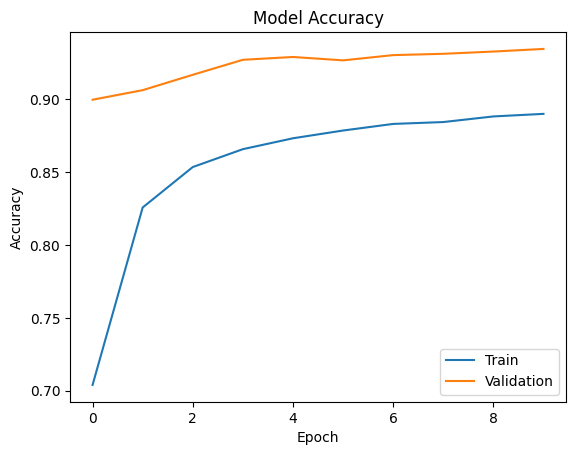

In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train','Validation'])
plt.show()

In [18]:
model.save("plants_disease_model.h5")

In [19]:
from tensorflow.keras.preprocessing import image

img_path = "test.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_names = list(train_data.class_indices.keys())

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Disease:", predicted_class)

FileNotFoundError: [Errno 2] No such file or directory: 'test.jpg'